## Regresión Espacial

In [2]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from pysal.model import spreg
from pysal.lib import weights
from pysal.explore import esda
from scipy import stats
import statsmodels.formula.api as sm
import numpy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sbn

In [3]:


df = gpd.read_file('../data/regresion_POMCA.geojson')

In [3]:
df.info()
df.columns

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Id                 95 non-null     object  
 1   AH                 95 non-null     int32   
 2   NOMAH              95 non-null     object  
 3   ZH                 95 non-null     int32   
 4   NOMZH              95 non-null     object  
 5   SZH                95 non-null     int32   
 6   NOMSZH             95 non-null     object  
 7   Area_Ha            95 non-null     float64 
 8   num_species        95 non-null     int32   
 9   num_points         95 non-null     int32   
 10  bio1_mean          95 non-null     float64 
 11  bio3_mean          95 non-null     float64 
 12  bio4_mean          95 non-null     float64 
 13  bio7_mean          95 non-null     float64 
 14  bio12_mean         95 non-null     float64 
 15  bio15_mean         95 non-null     float64 
 16  el

Index(['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha',
       'num_species', 'num_points', 'bio1_mean', 'bio3_mean', 'bio4_mean',
       'bio7_mean', 'bio12_mean', 'bio15_mean', 'elevacion', 'sp_density',
       'num_species_std', 'w_num_species_std', 'num_points_std',
       'w_num_points_std', 'sp_density_std', 'w_sp_density_std', 'geometry'],
      dtype='object')

In [4]:
import numpy as np

df['log_sp_density'] = df['sp_density'].apply(lambda x: 0 if x == 0 else np.log(x))
df['log_sp_density_std'] = df['sp_density_std'].apply(lambda x: 0 if x == 0 else np.log(x))

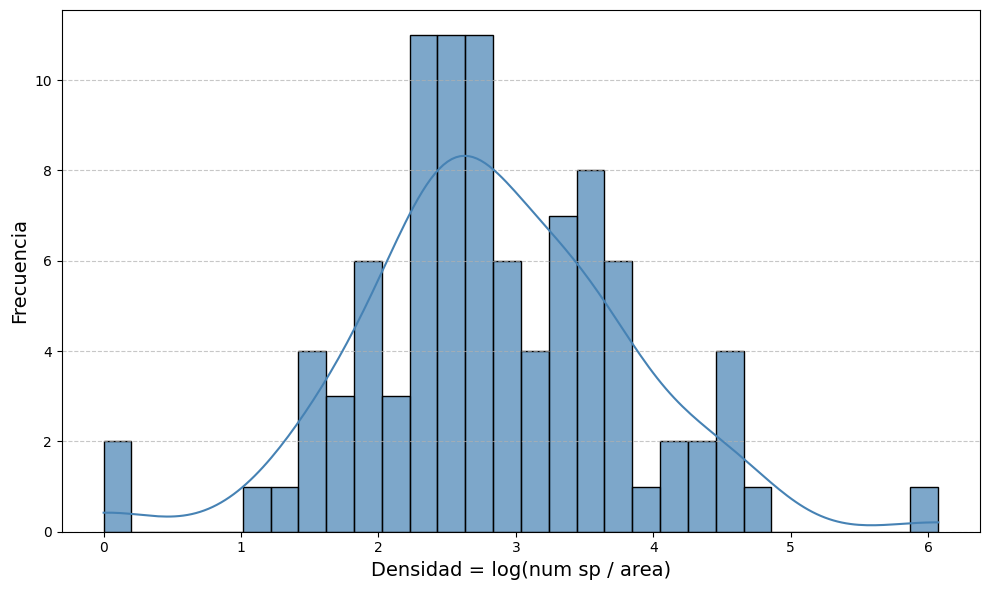

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Histograma con línea de densidad
sns.histplot(df['log_sp_density'], bins=30, kde=True, color='steelblue', edgecolor='black', alpha=0.7)

# Título y etiquetas
plt.title('', fontsize=16)
plt.xlabel('Densidad = log(num sp / area)', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)

# Rejilla
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar
plt.tight_layout()
plt.show()


In [13]:
variable_names = ['bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean',
       'bio12_mean', 'bio15_mean']
df[variable_names].corr()

,bio1_mean,bio3_mean,bio4_mean,bio7_mean,bio12_mean,bio15_mean
bio1_mean,1.000000,-0.053046,0.325303,0.165997,0.469936,0.148913
bio3_mean,-0.053046,1.000000,-0.848615,-0.685786,0.321944,-0.858379
bio4_mean,0.325303,-0.848615,1.000000,0.590116,-0.140510,0.758509
bio7_mean,0.165997,-0.685786,0.590116,1.000000,-0.425823,0.646023
bio12_mean,0.469936,0.321944,-0.140510,-0.425823,1.000000,-0.389423
bio15_mean,0.148913,-0.858379,0.758509,0.646023,-0.389423,1.000000


In [7]:
print(df.shape)
df.columns

(95, 27)


Index(['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha',
       'num_species', 'num_points', 'bio1_mean', 'bio3_mean', 'bio4_mean',
       'bio7_mean', 'bio12_mean', 'bio15_mean', 'elevacion', 'sp_density',
       'num_species_std', 'w_num_species_std', 'num_points_std',
       'w_num_points_std', 'sp_density_std', 'w_sp_density_std', 'geometry',
       'log_sp_density', 'log_sp_density_std'],
      dtype='object')

In [ ]:
# Probamos el primer modelo de regresión lineal
variable_names = ['bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean',
       'bio12_mean', 'bio15_mean','elevacion']


m1 = spreg.OLS(df[['log_sp_density']].values, 
               df[variable_names].values, 
               name_y='log_species_density', 
               name_x=variable_names)



In [9]:
print(m1.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log_species_density                Number of Observations:          95
Mean dependent var  :      2.8370                Number of Variables   :           8
S.D. dependent var  :      0.9735                Degrees of Freedom    :          87
R-squared           :      0.4583
Adjusted R-squared  :      0.4147
Sum squared residual:     48.2609                F-statistic           :     10.5139
Sigma-square        :       0.555                Prob(F-statistic)     :   1.654e-09
S.E. of regression  :       0.745                Log likelihood        :    -102.629
Sigma-square ML     :       0.508                Akaike info criterion :     221.259
S.E of regression ML:      0.7127                Schwarz criterion     :     241.690

-----------------------------------------------------

In [ ]:
m0=sm.ols("log_sp_density ~ bio1_mean + bio3_mean + bio4_mean + bio7_mean + bio12_mean + bio15_mean + elevacion", data=df).fit()

In [11]:
print(m0.summary())

                            OLS Regression Results                            
Dep. Variable:         log_sp_density   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     10.51
Date:               mar, 24 jun. 2025   Prob (F-statistic):           1.65e-09
Time:                        20:43:40   Log-Likelihood:                -102.63
No. Observations:                  95   AIC:                             221.3
Df Residuals:                      87   BIC:                             241.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     16.8790      5.732      2.945      0.0

Evaluamos los residuales por una variable de categoría

In [12]:
df.columns

Index(['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha',
       'num_species', 'num_points', 'bio1_mean', 'bio3_mean', 'bio4_mean',
       'bio7_mean', 'bio12_mean', 'bio15_mean', 'elevacion', 'sp_density',
       'num_species_std', 'w_num_species_std', 'num_points_std',
       'w_num_points_std', 'sp_density_std', 'w_sp_density_std', 'geometry',
       'log_sp_density', 'log_sp_density_std'],
      dtype='object')

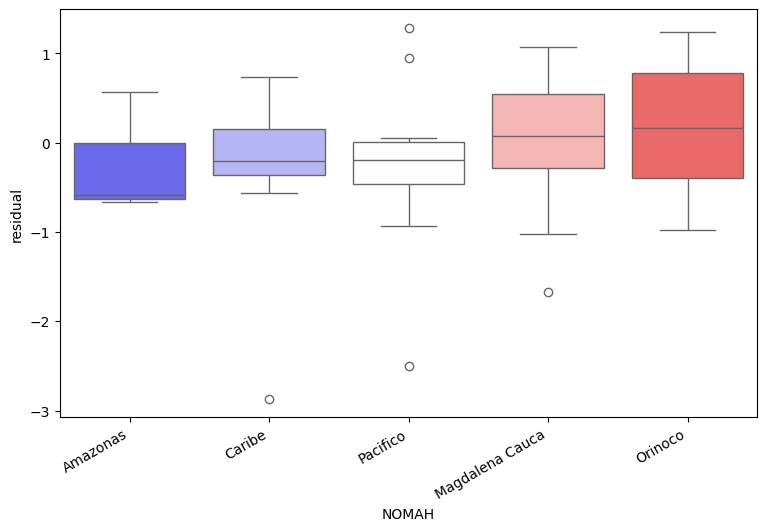

In [15]:
df['residual'] = m1.u
medians = df.groupby("NOMAH").residual.median().to_frame('basin_residual')

f = plt.figure(figsize=(9,6))
ax = plt.gca()
sbn.boxplot(x='NOMAH', y='residual', ax = ax,
                data=df.merge(medians, how='left',left_on='NOMAH',right_index=True).sort_values('basin_residual'), palette='bwr',  dodge=False)
f.autofmt_xdate()
plt.show()

Espacial lag de los residuales

In [15]:
# df_geo = gpd.GeoDataFrame(df, geometry='centroid')
knn = weights.KNN.from_dataframe(df, k=5)

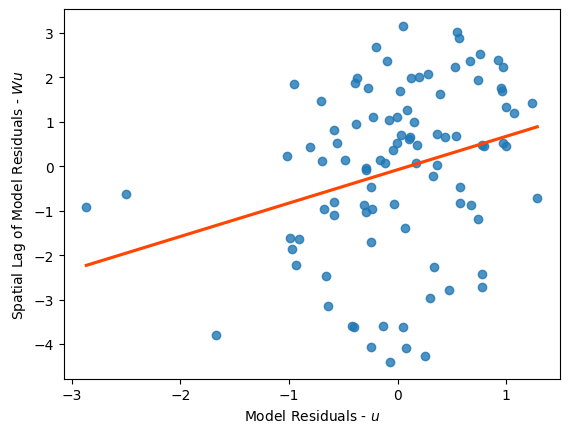

In [16]:
lag_residual = weights.spatial_lag.lag_spatial(knn, m1.u) # se obtiene la columna spatial_lag de la matris denominada Weights y se le calcula el espacial lag con la matriz de KNN
ax = sbn.regplot(x=m1.u.flatten(), y=lag_residual.flatten(),line_kws=dict(color='orangered'),ci=None)
ax.set_xlabel('Model Residuals - $u$')
ax.set_ylabel('Spatial Lag of Model Residuals - $W u$');

## Efectos de autocorrelación exógena entre las variables predictoras

In [16]:
%matplotlib inline

from pysal.model import spreg
from pysal.lib import weights
from pysal.explore import esda
from scipy import stats
import statsmodels.formula.api as sm
import numpy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sbn

In [17]:
variable_names = ['bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean',
       'bio12_mean', 'bio15_mean','elevacion']
knn = weights.KNN.from_dataframe(df, k=7)

In [18]:
df2 = df.copy()

In [19]:
for var in variable_names:
    df2['pg_' + var] = df2[var]

In [20]:
wx = df2.filter(like='pg')\
        .apply(lambda y: weights.spatial_lag.lag_spatial(knn, y))\
        .rename(columns=lambda c: 'w_' + c)

In [21]:
slx_exog = df2[variable_names].join(wx)
m5 = spreg.OLS(
    df2[['log_sp_density']].values,      
    slx_exog.values,                     
    name_y='log_sp_density',
    name_x=slx_exog.columns.tolist()
)


print(m5.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log_sp_density                Number of Observations:          95
Mean dependent var  :      2.8370                Number of Variables   :          15
S.D. dependent var  :      0.9735                Degrees of Freedom    :          80
R-squared           :      0.5284
Adjusted R-squared  :      0.4459
Sum squared residual:      42.012                F-statistic           :      6.4029
Sigma-square        :       0.525                Prob(F-statistic)     :   2.046e-08
S.E. of regression  :       0.725                Log likelihood        :     -96.043
Sigma-square ML     :       0.442                Akaike info criterion :     222.086
S.E of regression ML:      0.6650                Schwarz criterion     :     260.394

----------------------------------------------------------

### Efectos de autocorrelación endógena con el error espacial

In [22]:
m6 = spreg.GM_Error_Het(df[['log_sp_density']].values, 
                        df[variable_names].values,                        
                        w=knn, 
                        name_y='log_sp_density', 
                        name_x=variable_names)


print(m6.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :log_sp_density                Number of Observations:          95
Mean dependent var  :      2.8370                Number of Variables   :           8
S.D. dependent var  :      0.9735                Degrees of Freedom    :          87
Pseudo R-squared    :      0.4572
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        15.66589         6.39914         2.44812         0.01436
           bio1_mean         0.20646         0.21461  

### Efectos de autocorrelación endógena con la variable dependiente

In [ ]:
m7 = spreg.GM_Lag(df[['log_sp_density']].values, 
                  df[variable_names].values, 
                  w=knn, 
                  name_y='log_sp_density', 
                  name_x=variable_names)


print(m7.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :log_sp_density                Number of Observations:          95
Mean dependent var  :      2.8370                Number of Variables   :           9
S.D. dependent var  :      0.9735                Degrees of Freedom    :          86
Pseudo R-squared    :      0.5020
Spatial Pseudo R-squared:  0.4920

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         8.79511         6.07202         1.44846         0.14749
           bio1_mean         0.15252         0.16885         0.90327         0.36638
           bio3_mean        -0.11754    

## Ejemplo con cuencas

In [27]:
# Cargar datos
gdf = df.copy()

In [29]:
gdf.columns

Index(['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha',
       'num_species', 'num_points', 'bio1_mean', 'bio3_mean', 'bio4_mean',
       'bio7_mean', 'bio12_mean', 'bio15_mean', 'elevacion', 'sp_density',
       'num_species_std', 'w_num_species_std', 'num_points_std',
       'w_num_points_std', 'sp_density_std', 'w_sp_density_std', 'geometry',
       'log_sp_density', 'log_sp_density_std', 'residual'],
      dtype='object')

In [28]:
import geopandas as gpd
import numpy as np
import libpysal
from libpysal.weights import Queen
from sklearn.preprocessing import StandardScaler
import spreg

# Definir las variables dependiente e independientes
y = gdf['log_sp_density'].values.reshape((-1, 1))
independent_vars = ['bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean',
       'bio12_mean', 'bio15_mean','elevacion']
X = gdf[independent_vars].values

# Escalar las variables independientes
st = StandardScaler()
X_scaled = st.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=independent_vars)

# Crear la matriz de pesos espaciales por contigüidad tipo Queen
w = knn

# Calcular la autocorrelación exógena de las variables independientes escaladas
wx_dict = {}
for var in independent_vars:
    wx_dict[f'w_{var}'] = libpysal.weights.spatial_lag.lag_spatial(w, X_scaled_df[var])

wx_df = pd.DataFrame(wx_dict)

# Combinar las variables independientes originales escaladas con sus versiones espacialmente rezagadas
slx_exog = pd.concat([X_scaled_df, wx_df], axis=1)

# Ajustar el modelo OLS con las variables exógenas espacialmente rezagadas (SLX)
ols_model_slx = spreg.OLS(gdf['log_sp_density'].values.reshape((-1, 1)),
                          slx_exog.values,
                          name_y='log_sp_density',
                          name_x=slx_exog.columns.tolist(),
                          name_w='queen_contiguity')

# Imprimir el resumen del modelo OLS con SLX
print(ols_model_slx.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log_sp_density                Number of Observations:          95
Mean dependent var  :      2.8370                Number of Variables   :          15
S.D. dependent var  :      0.9735                Degrees of Freedom    :          80
R-squared           :      0.5284
Adjusted R-squared  :      0.4459
Sum squared residual:      42.012                F-statistic           :      6.4029
Sigma-square        :       0.525                Prob(F-statistic)     :   2.046e-08
S.E. of regression  :       0.725                Log likelihood        :     -96.043
Sigma-square ML     :       0.442                Akaike info criterion :     222.086
S.E of regression ML:      0.6650                Schwarz criterion     :     260.394

----------------------------------------------------------

### Modelo resagando el error

In [ ]:
# Ajustar el modelo de error espacial (GM_Error_Het)
spt_error = spreg.GM_Error_Het(y, X_scaled, w=w,
                                        name_y='log_sp_density',
                                      name_x=independent_vars,
                                      name_w='knn_weights')

# Imprimir el resumen del modelo de error espacial
print(spt_error.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------
Data set            :     unknown
Weights matrix      : knn_weights
Dependent Variable  :log_sp_density                Number of Observations:          95
Mean dependent var  :      2.8370                Number of Variables   :           8
S.D. dependent var  :      0.9735                Degrees of Freedom    :          87
Pseudo R-squared    :      0.4572
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         2.83356         0.10917        25.95534         0.00000
           bio1_mean         0.72426         0.75285  

### Modelo con retardo espacial

In [31]:
# Ajustar el modelo de retardo espacial (GM_Lag)
spatial_lag_model = spreg.GM_Lag(y, X_scaled, w=w,
                                name_y='log_sp_density',
                                name_x=independent_vars,
                                name_w='knn_weights')

# Imprimir el resumen del modelo de retardo espacial
print(spatial_lag_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      : knn_weights
Dependent Variable  :log_sp_density                Number of Observations:          95
Mean dependent var  :      2.8370                Number of Variables   :           9
S.D. dependent var  :      0.9735                Degrees of Freedom    :          86
Pseudo R-squared    :      0.5020
Spatial Pseudo R-squared:  0.4920

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         1.38770         0.54866         2.52926         0.01143
           bio1_mean         0.53504         0.59234         0.90327         0.36638
           bio3_mean        -0.58723    

### Modelos de Regresión para Heterogeneidad Espacial

In [32]:
%matplotlib inline

from pysal.model import spreg
from pysal.lib import weights
from pysal.explore import esda
from scipy import stats
import statsmodels.formula.api as sm
import numpy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sbn

In [35]:
df.columns

Index(['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha',
       'num_species', 'num_points', 'bio1_mean', 'bio3_mean', 'bio4_mean',
       'bio7_mean', 'bio12_mean', 'bio15_mean', 'elevacion', 'sp_density',
       'num_species_std', 'w_num_species_std', 'num_points_std',
       'w_num_points_std', 'sp_density_std', 'w_sp_density_std', 'geometry',
       'log_sp_density', 'log_sp_density_std', 'residual'],
      dtype='object')

In [33]:
m3=sm.ols("log_sp_density ~ bio1_mean + bio3_mean + bio4_mean + bio7_mean + bio12_mean + bio15_mean + elevacion + NOMAH", data=df).fit()
print(m3.summary2())

                    Results: Ordinary least squares
Model:                 OLS                Adj. R-squared:       0.436   
Dependent Variable:    log_sp_density     AIC:                  221.2230
Date:                  2025-06-25 07:24   BIC:                  251.8695
No. Observations:      95                 Log-Likelihood:       -98.611 
Df Model:              11                 F-statistic:          7.612   
Df Residuals:          83                 Prob (F-statistic):   6.53e-09
R-squared:             0.502              Scale:                0.53429 
------------------------------------------------------------------------
                          Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
------------------------------------------------------------------------
Intercept                18.8773   6.3747  2.9613 0.0040  6.1983 31.5562
NOMAH[T.Caribe]           0.2290   0.5566  0.4114 0.6819 -0.8780  1.3359
NOMAH[T.Magdalena Cauca]  0.7096   0.5462  1.2990 0.1975 -0.3769  1.7961

In [34]:
# PySAL implementation
m4 = spreg.OLS_Regimes(df[['log_sp_density']].values, df[variable_names].values,
                       df['NOMAH'].tolist(),
                       constant_regi='many', cols2regi=[False]*len(variable_names),
                       regime_err_sep=False,
                       name_y='log_sp_density', name_x=variable_names)
print(m4.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES - REGIMES
---------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log_sp_density                Number of Observations:          95
Mean dependent var  :      2.8370                Number of Variables   :          12
S.D. dependent var  :      0.9735                Degrees of Freedom    :          83
R-squared           :      0.5022
Adjusted R-squared  :      0.4362
Sum squared residual:     44.3464                F-statistic           :      7.6125
Sigma-square        :       0.534                Prob(F-statistic)     :   6.533e-09
S.E. of regression  :       0.731                Log likelihood        :     -98.611
Sigma-square ML     :       0.467                Akaike info criterion :     221.223
S.E of regression ML:      0.6832                Schwarz criterion     :     251.870

--------------------------------------

In [46]:
region_effects = m3.params.filter(like='NOMAH')
region_effects.head()

NOMAH[T.Caribe]             0.228958
NOMAH[T.Magdalena Cauca]    0.709591
NOMAH[T.Orinoco]            0.797618
NOMAH[T.Pacifico]           0.149697
dtype: float64

### Intercepto y coeficientes variables

In [35]:
df_reg = df[df['NOMAH'].isin(['Magdalena Cauca', 'Orinoco', 'Pacifico', 'Caribe'])].copy()
m4 = spreg.OLS_Regimes(df_reg[['log_sp_density']].values, df_reg[variable_names].values,
                          df_reg['NOMAH'].tolist(),
                          constant_regi='many',
                          regime_err_sep=False,
                          name_y='log_sp_density', name_x=variable_names)
print(m4.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES - REGIMES
---------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log_sp_density                Number of Observations:          92
Mean dependent var  :      2.8629                Number of Variables   :          32
S.D. dependent var  :      0.9649                Degrees of Freedom    :          60
R-squared           :      0.6743
Adjusted R-squared  :      0.5061
Sum squared residual:     27.5912                F-statistic           :      4.0077
Sigma-square        :       0.460                Prob(F-statistic)     :   2.047e-06
S.E. of regression  :       0.678                Log likelihood        :     -75.145
Sigma-square ML     :       0.300                Akaike info criterion :     214.290
S.E of regression ML:      0.5476                Schwarz criterion     :     294.987

--------------------------------------